# GISC 4381/6321 — Lab 4 Tasks: Networks and Spatial Weights

Complete these after working through `NetworkX_PySAL_Walkthrough.ipynb`.

Run this setup cell first.


In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

import geopandas as gpd
import libpysal
from libpysal.weights import Queen, Rook, KNN, DistanceBand, block_weights, higher_order, lag_spatial
from shapely.geometry import box, Point

%matplotlib inline
plt.rcParams["figure.figsize"] = (5, 5)
np.random.seed(4381)


/tmp/ipykernel_768/1486655104.py:5: DeprecationWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas still uses PyGEOS by default. However, starting with version 0.14, the default will switch to Shapely. To force to use Shapely 2.0 now, you can either uninstall PyGEOS or set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In the next release, GeoPandas will switch to using Shapely by default, even if PyGEOS is installed. If you only have PyGEOS installed to get speed-ups, this switch should be smooth. However, if you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


---
## Task 1: Directed vs. Undirected (NetworkX)

Build a **directed graph** representing a small "who-follows-whom" social media network with these
follow relationships:

- Ana follows Ben
- Ben follows Ana
- Ben follows Cleo
- Cleo follows Dax
- Dax follows Ana
- Eve follows Cleo (but nobody follows Eve back)

**Questions:**
1. Is this graph strongly connected? Weakly connected? Explain in one sentence why the answer
   makes sense given Eve's position.
2. What is Eve's **in-degree** and **out-degree**? What does the difference mean in a "who
   follows whom" context?


---
## Task 2: Weighted Shortest Paths (NetworkX)

A small delivery network has roads with the following **drive times in minutes**:

| From | To | Minutes |
|---|---|---|
| Warehouse | Stop1 | 8 |
| Warehouse | Stop2 | 20 |
| Stop1 | Stop2 | 5 |
| Stop1 | Stop3 | 15 |
| Stop2 | Stop3 | 4 |

**Questions:**
1. Build this as an undirected, weighted graph.
2. Find the shortest path from `Warehouse` to `Stop3` (a) by number of hops, and (b) by total
   drive time. Do they agree?
3. In your own words, when would a delivery company care about (a) instead of (b)?


---
## Task 3: Centrality and Critical Infrastructure (NetworkX)

Below is code that builds a small airport network. Run it, then answer the questions.


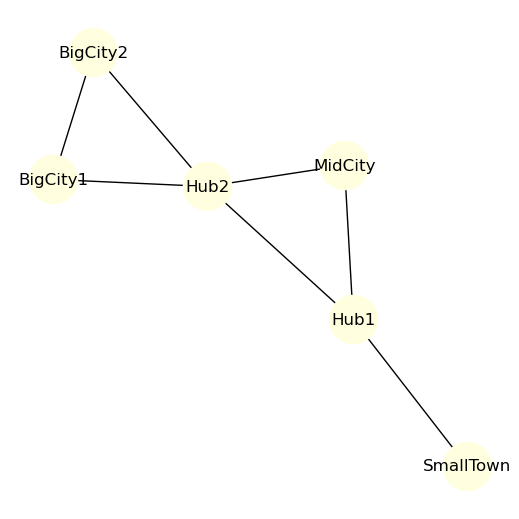

In [4]:
airports = nx.Graph()
airports.add_edges_from([
    ("SmallTown", "Hub1"),
    ("Hub1", "Hub2"),
    ("Hub1", "MidCity"),
    ("Hub2", "MidCity"),
    ("Hub2", "BigCity1"),
    ("Hub2", "BigCity2"),
    ("BigCity1", "BigCity2"),
])

pos = nx.spring_layout(airports, seed=10)
nx.draw(airports, pos, with_labels=True, node_color="lightyellow", node_size=1200)
plt.show()


**Questions:**
1. Compute degree, closeness, and betweenness centrality for every airport.
2. Which single airport, if shut down (e.g., for weather), would most disrupt travel between
   `SmallTown` and the two `BigCity` airports? Justify using one of the three centrality measures
   — and explain why that measure (rather than the other two) is the right one for this question.


---
## Task 4: Friendship Paradox on a Different Network Structure

The walkthrough demonstrated the friendship paradox on an Erdős–Rényi random graph
(`nx.erdos_renyi_graph`), where every pair of nodes has an equal chance of being connected.

Now repeat the experiment on a **scale-free network** — one with a few very highly-connected
"hub" nodes, which is a much better model of real social networks — using
`nx.barabasi_albert_graph(n=200, m=3, seed=1)`.

**Questions:**
1. Compute the average degree and the average friend-degree, as in the walkthrough.
2. Is the *gap* between them bigger or smaller than it was for the random graph? Why do you think
   that is, given that this network has hub nodes?


---
## Task 5: Rook vs. Queen on an Irregular Layout (PySAL)

The walkthrough used a clean, regular 4×4 grid. Real administrative boundaries are messier. Below
is code that builds 6 irregular polygons, including two that meet only at a single corner.


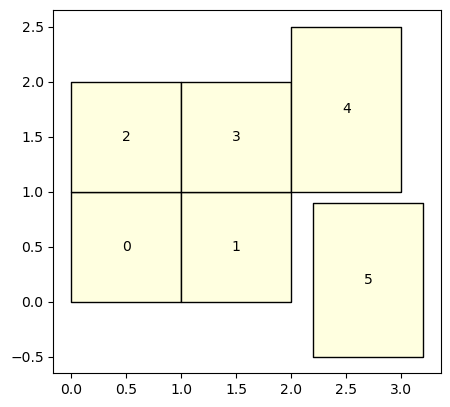

In [8]:
polys6 = [
    box(0, 0, 1, 1),      # 0 bottom-left
    box(1, 0, 2, 1),      # 1 bottom-right
    box(0, 1, 1, 2),      # 2 top-left
    box(1, 1, 2, 2),      # 3 top-right  -- shares only the corner (1,1) with polygon 0
    box(2, 1, 3, 2.5),    # 4 an irregular neighbor of polygon 3
    box(2.2, -0.5, 3.2, 0.9),  # 5 offset so it only nicks a corner of polygon 1
]
gdf6 = gpd.GeoDataFrame({"id": range(6)}, geometry=polys6)
ax = gdf6.plot(edgecolor="black", facecolor="lightyellow", figsize=(5, 5))
for i, geom in zip(gdf6["id"], gdf6.geometry):
    ax.annotate(str(i), (geom.centroid.x, geom.centroid.y), ha="center", va="center")
plt.show()


**Questions:**
1. Compute both `Rook` and `Queen` weights for `gdf6`.
2. For which pair(s) of polygons do rook and queen *disagree* (i.e., queen sees them as neighbors
   but rook doesn't)? Confirm your answer matches what you see in the plot.
3. If you were building a weight matrix to study **disease spread through shared building walls
   or hallways**, would you pick rook or queen? What if you were studying **wildfire spread by
   embers jumping short gaps**? Justify each choice in a sentence.


---
## Task 6: The "Island" Problem with KNN and Distance Band (PySAL)

Below is code that creates 10 points clustered together, plus one point far away (like Hawaii
relative to the continental US states in lecture).


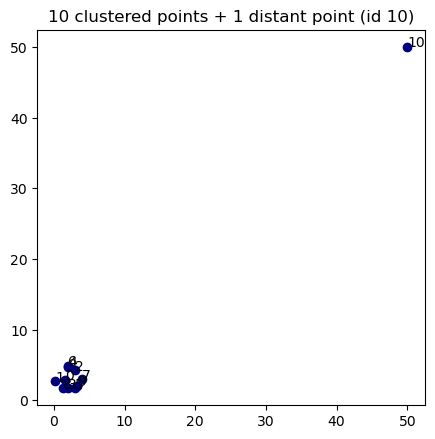

In [10]:
np.random.seed(4381)
cluster_pts = [Point(x, y) for x, y in np.random.uniform(0, 5, size=(10, 2))]
far_pt = [Point(50, 50)]  # our "Hawaii"

pts_gdf = gpd.GeoDataFrame({"id": range(11)}, geometry=cluster_pts + far_pt)

ax = pts_gdf.plot(color="navy")
for i, geom in zip(pts_gdf["id"], pts_gdf.geometry):
    ax.annotate(str(i), (geom.x, geom.y))
plt.title("10 clustered points + 1 distant point (id 10)")
plt.show()


**Questions:**
1. Build a `DistanceBand` weight with `threshold=2.0`. What happens to point 10? Look up (or
   recall from the walkthrough) what PySAL/the lecture calls a location with zero neighbors.
2. Build a `KNN` weight with `k=3`. Does point 10 have neighbors now? Are they *good* neighbors in
   any meaningful geographic sense?
3. Which problem is worse for a spatial analysis: the island from DistanceBand, or the
   nonsensical neighbors from KNN? There's no single right answer — argue for one, briefly.


---
## Task 7: Reading a Connectivity Histogram

You're handed someone else's `Queen` weight matrix, `w_mystery`, built from real county
polygons, and its connectivity histogram is:

```
{0: 2, 1: 3, 2: 5, 3: 9, 4: 22, 5: 30, 6: 25, 7: 10, 8: 3, 14: 1}
```

(Format: `{number_of_neighbors: count_of_counties_with_that_many}`.)

**Questions:**
1. How many counties have zero neighbors? What real-world situation might cause that (think about
   what kind of geographic feature could isolate a county on a map)?
2. One county has 14 neighbors — dramatically more than everyone else. Why might a single
   observation with that many neighbors be a problem when you later compute a spatial lag for it?
3. Propose one concrete fix for each problem (you don't need code — just describe it in a sentence).


---
## Task 8: Spatial Lag and Its Limits

Use the 4×4 grid (`gdf`) and queen weights (`w_queen`) from the walkthrough notebook, or rebuild
them below. This time, the attribute is **grocery store density** (stores per grid cell), and
`price` from the walkthrough is unrelated here — pretend we're studying food access instead.


In [13]:
n_side = 4
polys = [box(c, r, c + 1, r + 1) for r in range(n_side) for c in range(n_side)]
gdf8 = gpd.GeoDataFrame({"id": range(16)}, geometry=polys)

# Almost no stores, except one well-stocked cell in the middle
np.random.seed(1)
gdf8["stores"] = np.random.poisson(0.3, size=16)
gdf8.loc[5, "stores"] = 8  # one cell (interior) has a big supermarket cluster

w = Queen.from_dataframe(gdf8, use_index=False)
w.transform = "r"
gdf8["stores_lag"] = lag_spatial(w, gdf8["stores"])

gdf8[["id", "stores", "stores_lag"]]


,id,stores,stores_lag
0,0,0,2.666667
1,1,0,1.600000
2,2,0,1.600000
3,3,0,0.000000
4,4,0,1.600000
5,5,8,0.000000
6,6,0,1.000000
7,7,0,0.000000
8,8,0,1.800000
9,9,0,1.125000


**Questions:**
1. Which cell has the highest spatial lag value, and is it the same cell that actually has 8
   stores? Explain why or why not.
2. Lecture warned that "spatial lag is just a weighted average — it is not a replacement for more
   specific models." Using this store example, describe a real food-access question that spatial
   lag of store *counts* **cannot** answer, and briefly describe what kind of model or additional
   data you would need instead. (Hint: think about what "spatial accessibility" from lecture adds
   beyond a simple lag — e.g., driving time, road networks, store size/hours.)
